# Data Salaries Analysis 💸

## 1. Import Libraries and Load the Dataset

In [76]:
import pandas as pd

df = pd.read_csv(
    "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/Salaries.csv"
)
df.head()

,Unnamed: 0,rank,discipline,yrs.since.phd,yrs.service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


## 2. Data exploration
- 2.1. mean/median of all salaries.
- 2.2. median salary by gender.
- 2.3. median rank.
- 2.4. median title.

## 🌍 Data exploration

In [77]:
df.describe()

,Unnamed: 0,yrs.since.phd,yrs.service,salary
count,397.000000,397.000000,397.000000,397.000000
mean,199.000000,22.314861,17.614610,113706.458438
std,114.748275,12.887003,13.006024,30289.038695
min,1.000000,1.000000,0.000000,57800.000000
25%,100.000000,12.000000,7.000000,91000.000000
50%,199.000000,21.000000,16.000000,107300.000000
75%,298.000000,32.000000,27.000000,134185.000000
max,397.000000,56.000000,60.000000,231545.000000


### 2.1. Mean/Median of all Salaries

In [78]:
df["salary"].agg(["mean", "median"])

,salary
mean,113706.458438
median,107300.000000


### 2.2. Median Salary by Gender.

In [79]:
df.groupby("sex")["salary"].agg(["mean","median"])

,mean,median
sex,,
Female,101002.410256,103750.0
Male,115090.418994,108043.0


### 2.3. Median Salary by Rank.

In [80]:
df.groupby("rank")["salary"].agg(["mean","median"])

,mean,median
rank,,
AssocProf,93876.437500,95626.5
AsstProf,80775.985075,79800.0
Prof,126772.109023,123321.5


### 2.4. Median Salary by Title.

In [81]:
df.groupby("discipline")["salary"].agg(["mean","median"])

,mean,median
discipline,,
A,108548.430939,104350.0
B,118028.694444,113018.5


## 3. Data wrangling

*   3.1 Renaming columns.
*   3.2 Subsetting columns.
*   3.3 Handling missing data.

### 3.1 Renaming columns.

In [82]:
df = df.rename(
    columns={
        "Unnamed: 0": "id",
        "yrs.since.phd": "phd",
        "yrs.service": "service"
        }
    )
df.head()

,id,rank,discipline,phd,service,sex,salary
0,1,Prof,B,19,18,Male,139750
1,2,Prof,B,20,16,Male,173200
2,3,AsstProf,B,4,3,Male,79750
3,4,Prof,B,45,39,Male,115000
4,5,Prof,B,40,41,Male,141500


### 3.2 Subsetting columns

In [83]:
df_salary = df[["salary", "rank", "sex","phd"]]
df_salary.head()

,salary,rank,sex,phd
0,139750,Prof,Male,19
1,173200,Prof,Male,20
2,79750,AsstProf,Male,4
3,115000,Prof,Male,45
4,141500,Prof,Male,40


### 3.3 Handling missing data.

In [84]:
df_salary = df_salary.dropna()
df_salary = df_salary.drop_duplicates()
df_salary.head()

,salary,rank,sex,phd
0,139750,Prof,Male,19
1,173200,Prof,Male,20
2,79750,AsstProf,Male,4
3,115000,Prof,Male,45
4,141500,Prof,Male,40


## 4. Data wrangling

### 4.1. Salary Distribution — Distribución de salarios

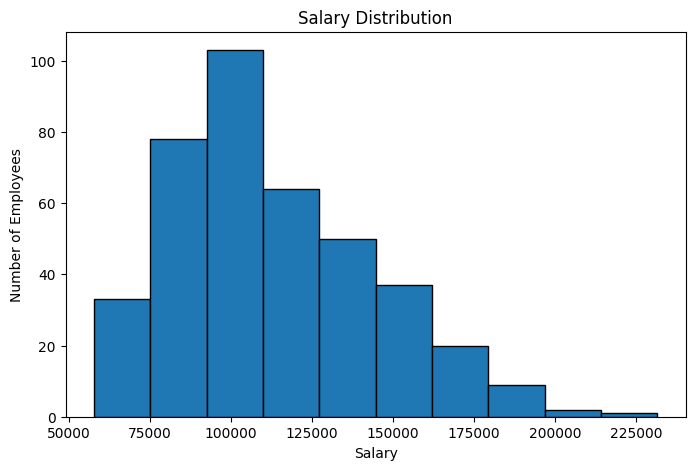

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df["salary"],
    bins=10,
    edgecolor="black"
    )

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.show()

### 4.2. Median Salary by Rank

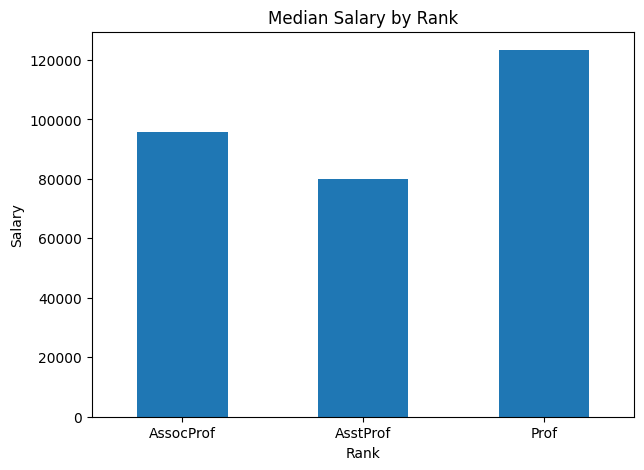

In [99]:
median_by_rank = df.groupby("rank")["salary"].median()
median_by_rank

plt.figure(figsize=(7,5))

median_by_rank.plot(kind="bar")

plt.title("Median Salary by Rank")
plt.xlabel("Rank")
plt.ylabel("Salary")
plt.xticks(rotation=0)


plt.show()

### 4.2. Median Salary by Rank

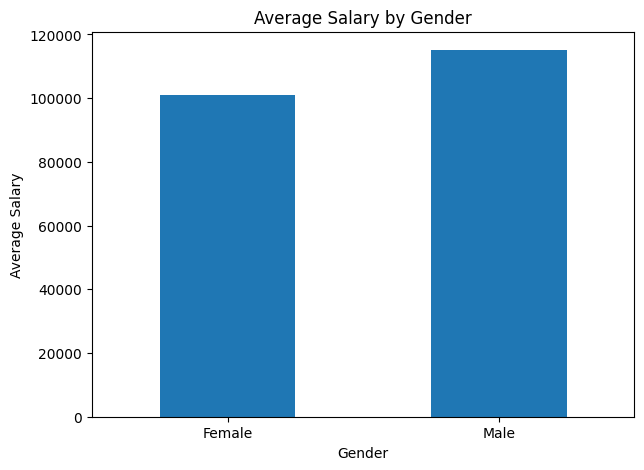

In [101]:
mean_by_gender = df.groupby("sex")["salary"].mean()

mean_by_gender

plt.figure(figsize=(7,5))

mean_by_gender.plot(kind="bar")

plt.title("Average Salary by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Salary")

plt.xticks(rotation=0)

plt.show()

## Conclusions - what did you discover?

The analysis shows that salaries vary considerably among faculty members. The average salary is approximately $113,706, while the median salary is $107,300. Because the mean is higher than the median, some higher salaries are increasing the overall average.

Academic rank appears to have an important relationship with salary. Professors generally earn more than Associate Professors and Assistant Professors, suggesting that higher academic rank is associated with higher salary.

The analysis also shows some differences between male and female salaries. Male faculty have a slightly higher median salary overall and within each academic rank. However, the dataset contains many more male faculty members than female faculty members, so this difference should be interpreted carefully.

Overall, academic rank appears to be one of the clearest factors associated with salary in this dataset. More analysis would be needed to determine how gender, years of service, years since PhD, and discipline affect salary.
